# Problema di assegnamento

* ### Aviojet è una società che gestisce i collegamenti navali con alcune isole.

* ### L’azienda ha il problema di assegnare cinque equipaggi ad altrettanti servizi di linea da effettuare. 

* ### A ogni assegnamento equipaggio-servizio è associato un costo, legato a diversi parametri, in particolare, la destinazione di ogni linea di servizio e l’anzianità di servizio di ciascun membro dell’equipaggio. Tali costi sono riportati nella Tabella:


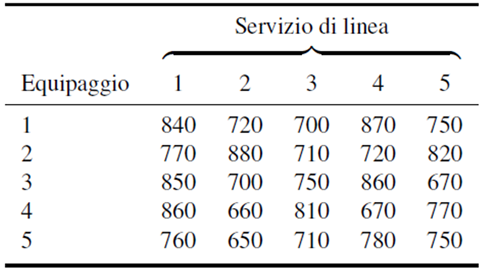

# Formulazione

## Variabili binarie

### <span style="color:purple">$x_{i,j}, \quad \quad i, j \in \{1,2,...,5\} $ </span>  

### La generica varibile <span style="color:purple">$x_{i,j}$ </span>  assume valore <span style="color:purple"> 1</span> se l'equipaggio <span style="color:purple">$𝑖$</span> è assegnato al servizio <span style="color:purple">$j$ </span>, <span style="color:purple">$0$</span> altrimenti.

In [1]:
# Legge la matrice dei costi e genera le variabili

import gurobipy as gp
from gurobipy import GRB

import numpy as np

file = open("Assegnamento.dat")

lines = file.readlines()
riga = lines[0].split(" ")

n = int(riga[2])

costo = np.zeros((n,n))

for i in range(n) :
    riga = lines[i+3].split("\t")
    for j in range(n):
        costo[i,j] = int(riga[j])
        
# Inizializza il modelo
mod = gp.Model('Assegnamento')

xvar = mod.addVars(range(n), range(n), vtype = GRB.BINARY, name="x")


FileNotFoundError: [Errno 2] No such file or directory: 'Assegnamento.dat'

## Funzione obiettivo

$$ \sum_{i = 1..n} \sum_{j = 1..n} c_{ij} x_{ij}$$

In [14]:
obj = (gp.quicksum(costo[i,j]*xvar[i,j] for i in range(n) for j in range(n)))
    
mod.setObjective(obj, GRB.MAXIMIZE)

## Vincoli sugli equipaggi

$$ \sum_{j = 1..n} x_{ij} = 1 \quad\quad i \in \{1,...,n\}$$

In [15]:
mod.addConstrs((xvar.sum(i,'*') == 1 for i in range(n)), name="Equipaggi")

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>}

## Vincoli sui servizi

$$ \sum_{i = 1..n} x_{ij} = 1 \quad\quad j \in \{1,...,n\}$$

In [16]:
mod.addConstrs((xvar.sum('*',j) == 1 for j in range(n)), name="Servizi")

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>}

# Soluzione del problema

### Risolve il problema

In [17]:
mod.write("prova.lp")

In [18]:
mod.optimize()

Gurobi Optimizer version 9.5.1 build v9.5.1rc2 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 10 rows, 25 columns and 50 nonzeros
Model fingerprint: 0x1fd33d00
Variable types: 0 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [7e+02, 9e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 3690.0000000
Presolve time: 0.00s
Presolved: 10 rows, 25 columns, 50 nonzeros
Variable types: 0 continuous, 25 integer (25 binary)

Root relaxation: objective 4.160000e+03, 8 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    4160.0000000 4160.00000  0.00%     -    0s

Explored 1 nodes (8 simplex iterations) in 0.04 seconds (0.00 work units)
Thread count

In [20]:
if mod.status == GRB.OPTIMAL:

    foundOptimalSol = True

    # print solution

    print('\nObj: %g \n' % mod.objVal)

    X = mod.getAttr('x', xvar)
    for i in range(n):
        for j in range(n) :
            if X[i,j] > 0 :
                print('X(%s,%s) = %g' % (i, j, X[i,j]))
 


Obj: 4160 

X(0,3) = 1
X(1,1) = 1
X(2,0) = 1
X(3,2) = 1
X(4,4) = 1
